# Gyroscope

In [111]:
import numpy as np
from utils import *
from scipy.linalg import expm, logm
import time

In [6]:
# initial attitude at identity
q0 = np.array([1, 0, 0, 0])

In [7]:
#sample random angular velocity
# ω0 = 0.5*np.random.randn(3)
ω0 = np.array([ 0.10778194, -0.79354571, -0.58183491])

#Constant velocity
h = 1/100 #time step
n = 100 #number of time steps
tf = n*h #final time

In [8]:
print(np.linalg.norm(ω0))

0.989880600347474


In [9]:
#Assume constant velocity (exact solution)
q = L(q0) @ expq(0.5*tf*ω0)

In [10]:
W_gyro = 1.04e-12*np.eye(3)*h #gyro noise covariance

In [11]:
#dynamics
def dynamics(x):
    q = x[0:4]
    ω = x[4:7]
    
    q̇ = 0.5 * G(q) @ ω
    ω̇ = np.zeros(3)

    return np.concatenate([q̇, ω̇])

In [12]:
#Classic RK4 integrator: https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods
def rkstep(x):
    f1 = dynamics(x)
    f2 = dynamics(x + 0.5*h*f1)
    f3 = dynamics(x + 0.5*h*f2)
    f4 = dynamics(x + h*f3)
    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    #xn[1:4] .= xn[1:4]/norm(xn[1:4]) #re-normalize quaternion
    return xn

In [13]:
#Simulate n time steps
x0 = np.concatenate([q0, ω0])
xk_true = np.zeros((n+1, 7))
xk_true[0] = x0
for k in range(n):
    xk_true[k+1] = rkstep(xk_true[k])

In [15]:
#Simulate n time steps over many runs to see distribution of final states
x0 = np.concatenate([q0, ω0])
n_runs = 100
xk_noisy = np.zeros((n_runs, n+1, 7))
for i in range(n_runs):
    xk_noisy[i][0] = x0
    for k in range(n):
        xk_noisy[i][k+1] = rkstep(xk_noisy[i][k])

        # add angle random walk noise to the quaternion
        noise = np.random.multivariate_normal(np.array([0, 0, 0]), W_gyro)
        xk_noisy[i][k+1][0:4] = xk_noisy[i][k+1][0:4] @ R(expq(0.5 * noise))


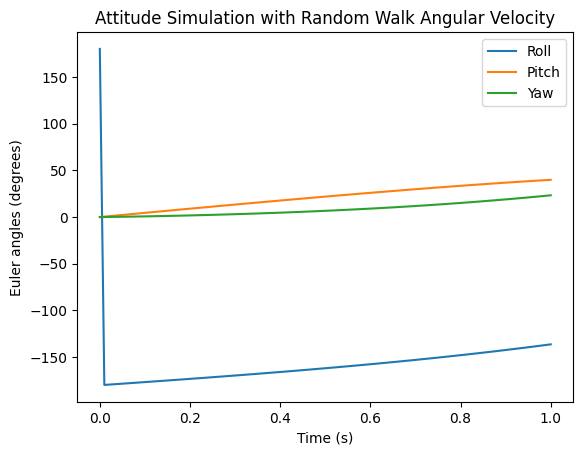

In [16]:
# plot the euler angles of xk over time
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
euler_angles = Rotation.from_quat(xk_true[:,0:4]).as_euler('xyz', degrees=True)
plt.plot(np.arange(n+1)*h, euler_angles)
plt.xlabel('Time (s)')
plt.ylabel('Euler angles (degrees)')
plt.legend(['Roll', 'Pitch', 'Yaw'])
plt.title('Attitude Simulation with Random Walk Angular Velocity')
plt.show()

In [17]:
# Print average error along each axis (in radians)
q_true = xk_true[-1][0:4]
avg_var = np.zeros(3)

for i in range(n_runs):
    q_noisy = xk_noisy[i][-1][0:4]
    error = unhat(logm(Q(q_noisy).T @ Q(q_true)))
    avg_var += error**2
avg_var /= n_runs
print(f'Standard deviation: {np.sqrt(avg_var)}')

Standard deviation: [1.01213617e-06 1.03593302e-06 1.01310574e-06]


# Star Tracker

In [18]:
#Make a random attitude
qtrue = expq(0.5*np.random.randn(3))
Qtrue = Q(qtrue) #equivalent rotation matrix

In [96]:
#Make some random vectors
n = 1000
def generate_gt_vecs(n, Qtrue):
    r_B = np.random.randn(3,n)
    for k in range(n):
        r_B[:,k] = r_B[:,k]/np.linalg.norm(r_B[:,k])
    r_N = Qtrue @ r_B
    return r_B, r_N
r_B, r_N = generate_gt_vecs(n, Qtrue)

In [105]:
#Add some noise
def generate_random_vecs(r_B, n, noise_std):
    r_B_noisy = r_B.copy()
    for k in range(n):
        # r_B_noisy[:,k] += 4.84814e-6 * np.random.randn(3)
        # r_B_noisy[:,k] = r_B_noisy[:,k] / np.linalg.norm(r_B_noisy[:,k])

        noise_dir = np.random.randn(3)
        noise_dir = noise_dir / np.linalg.norm(noise_dir)
        q_noise = expq(0.5*noise_dir*noise_std)
        r_B_noisy[:,k] = Q(q_noise) @ r_B[:,k]

        # noise_2d = np.random.multivariate_normal(np.zeros(2), (4.84814e-6**2)/2 * np.eye(2))
        # r_B_noisy[:,k] += noise_2d[0] * np.cross(r_B_noisy[:,k], np.array([0, 0, 1])) + noise_2d[1] * np.cross(r_B_noisy[:,k], np.array([0, 1, 0]))
        # r_B_noisy[:,k] = r_B_noisy[:,k] / np.linalg.norm(r_B_noisy[:,k])
    return r_B_noisy

star_tracker_noise_std = 4.84814e-6 #1 arcsecond in radians
r_B_noisy = generate_random_vecs(r_B, n, star_tracker_noise_std)

In [37]:
avg_var = 0
for k in range(n):
    dot = r_B_noisy[:,k].T @ r_B[:,k]
    if dot > 1 - 1e-24:
        error = 0
    else:
        error = np.arccos(np.clip(dot, -1.0, 1.0))
    avg_var += error**2

avg_var /= n
print(f'Standard deviation: {np.sqrt(avg_var)}')

Standard deviation: 3.970996296881598e-06


# Wahba

## q-Method

In [107]:
w = (1/n)*np.ones(n)

def qMethod(r_N, r_B, w):
    num_vecs = r_B.shape[1]
    #Davenport matrix
    D = np.zeros((4,4))
    for k in range(num_vecs):
        D += w[k]*L(H @ r_N[:,k]).T @ R(H @ r_B[:,k])
    eigenvals, eigenvecs = np.linalg.eig(D)
    q_qmethod = eigenvecs[:, np.argmax(eigenvals)]
    return q_qmethod

q_qmethod = qMethod(r_N, r_B_noisy, w)
print(f'q-Method error (degrees): {(180/np.pi)*np.linalg.norm(unhat(logm(Q(q_qmethod).T @ Qtrue)))}')

q-Method error (degrees): 1.4770704157300593e-05


## SVD

In [90]:
def svdMethod(r_N, r_B, w):
    num_vecs = r_B.shape[1]
    B = np.zeros((3,3))
    for k in range(num_vecs):
        B += w[k] * np.outer(r_B[:, k], r_N[:, k])
    U, S, Vt = np.linalg.svd(B)
    q_svd = expq(0.5 * unhat(logm(Vt.T @ U.T)))
    return q_svd

q_svd = svdMethod(r_N, r_B_noisy, w)
print(f'SVD method error (degrees): {(180/np.pi)*np.linalg.norm(unhat(logm(Q(q_svd).T @ Qtrue)))}')

SVD method error (degrees): 3.7084145626468003e-06


## Monte-Carlo

In [119]:
num_MCruns = 100
n_vecs_MC = 100

qtrue_MC = np.zeros((num_MCruns, 4))
r_B_noisy_MC = np.zeros((num_MCruns, 3, n_vecs_MC))
r_B_MC = np.zeros((num_MCruns, 3, n_vecs_MC))
r_N_MC = np.zeros((num_MCruns, 3, n_vecs_MC))
q_qmethod_MC = np.zeros((num_MCruns, 4))
q_svd_MC = np.zeros((num_MCruns, 4))
errors_qmethod_MC = np.zeros(num_MCruns)
errors_svd_MC = np.zeros(num_MCruns)
qmethod_times = np.zeros(num_MCruns)
svd_times = np.zeros(num_MCruns)

for i in range(num_MCruns):
    qtrue_MC[i] = expq(0.5*np.random.randn(3)) #random attitude
    r_B_MC[i], r_N_MC[i] = generate_gt_vecs(n_vecs_MC, Q(qtrue_MC[i]))
    r_B_noisy_MC[i] = generate_random_vecs(r_B_MC[i], n_vecs_MC, star_tracker_noise_std)

    # q-Method
    t0 = time.perf_counter()
    q_qmethod_MC[i] = qMethod(r_N_MC[i], r_B_noisy_MC[i], w)
    qmethod_times[i] = time.perf_counter() - t0
    errors_qmethod_MC[i] = (180/np.pi)*np.linalg.norm(unhat(logm(Q(q_qmethod_MC[i]).T @ Q(qtrue_MC[i]))))

    # SVD method
    t0 = time.perf_counter()
    q_svd_MC[i] = svdMethod(r_N_MC[i], r_B_noisy_MC[i], w)
    svd_times[i] = time.perf_counter() - t0
    errors_svd_MC[i] = (180/np.pi)*np.linalg.norm(unhat(logm(Q(q_svd_MC[i]).T @ Q(qtrue_MC[i]))))

print(f'qMethod runtime (s): mean={np.mean(qmethod_times):.6f}, std={np.std(qmethod_times):.6f}')
print(f'q-Method Monte Carlo error (degrees): mean={np.mean(errors_qmethod_MC):.6e}, std={np.std(errors_qmethod_MC):.6e}')
print(f'SVD method runtime (s): mean={np.mean(svd_times):.6f}, std={np.std(svd_times):.6f}')
print(f'SVD method Monte Carlo error (degrees): mean={np.mean(errors_svd_MC):.6e}, std={np.std(errors_svd_MC):.6e}')

qMethod runtime (s): mean=0.002490, std=0.000123
q-Method Monte Carlo error (degrees): mean=3.069551e-05, std=1.130386e-05
SVD method runtime (s): mean=0.001003, std=0.000141
SVD method Monte Carlo error (degrees): mean=3.069551e-05, std=1.130386e-05
